In [1]:
import torch # pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import cv2, os, shutil, glob, json
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
from utils.Files import *
pd.set_option('display.max_columns', None)

In [2]:
OPTIONS = json.loads(open('../Task/info.json', 'r').read())
OPTIONS

{'img_size': [4, 128, 128],
 'step': 3,
 'network': 'unet3d_v2',
 'lr': 0.0001,
 'loss': 'dice_focal',
 'batch_size': 4,
 'scheduler': 'plateau',
 'dropout': 0.1,
 'num_filters': 16}

In [3]:
MULTICLASS = True
AUG_PER_IMAGE = 0

In [4]:
images = [np.load(img) for img in getFiles('Database/Target/images')]
masks  = [np.load(img) for img in getFiles('Database/Target/masks')]

n_images = len(images)
IMG_SIZE = images[0].shape
print(n_images, IMG_SIZE)
images[:5]

22270 (4, 128, 128)


[array([[[0.5026313 , 0.5026313 , 0.5026313 , ..., 0.45398232,
          0.45757064, 0.46159425],
         [0.5026313 , 0.5026313 , 0.5026313 , ..., 0.44910604,
          0.4527773 , 0.45565534],
         [0.5026313 , 0.5026313 , 0.5026313 , ..., 0.45219803,
          0.457582  , 0.46895623],
         ...,
         [0.5026313 , 0.5026313 , 0.5026313 , ..., 0.49723858,
          0.4920319 , 0.48441008],
         [0.5026313 , 0.5026313 , 0.5026313 , ..., 0.4827063 ,
          0.47786868, 0.47352067],
         [0.5026313 , 0.5026313 , 0.5026313 , ..., 0.47623354,
          0.47256964, 0.47472328]],
 
        [[0.5026313 , 0.5026313 , 0.5026313 , ..., 0.46095577,
          0.4642003 , 0.4650347 ],
         [0.5026313 , 0.5026313 , 0.5026313 , ..., 0.45365933,
          0.45661938, 0.4621381 ],
         [0.5026313 , 0.5026313 , 0.5026313 , ..., 0.45378688,
          0.46045375, 0.47266814],
         ...,
         [0.5026313 , 0.5026313 , 0.5026313 , ..., 0.5016018 ,
          0.4961139 , 0.

# VERIFICAÇÃO DE INTEGRIDADE

In [5]:
len(images) == len(masks)

True

In [6]:
np.unique(images[:30])

array([0.0000000e+00, 4.1362431e-04, 4.8894045e-04, ..., 9.9894977e-01,
       9.9898684e-01, 1.0000000e+00], shape=(1367880,), dtype=float32)

In [7]:
np.unique(masks[:30])

array([0., 1., 2., 3., 4.], dtype=float32)

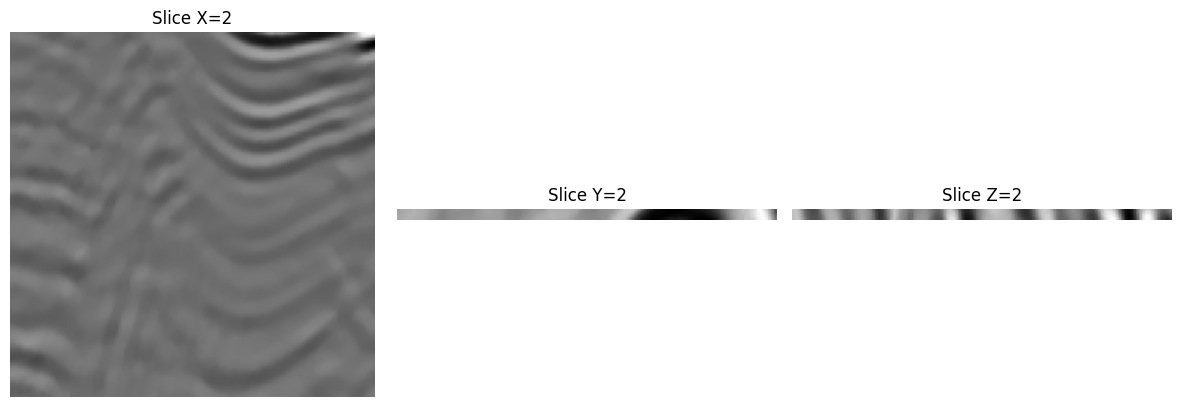

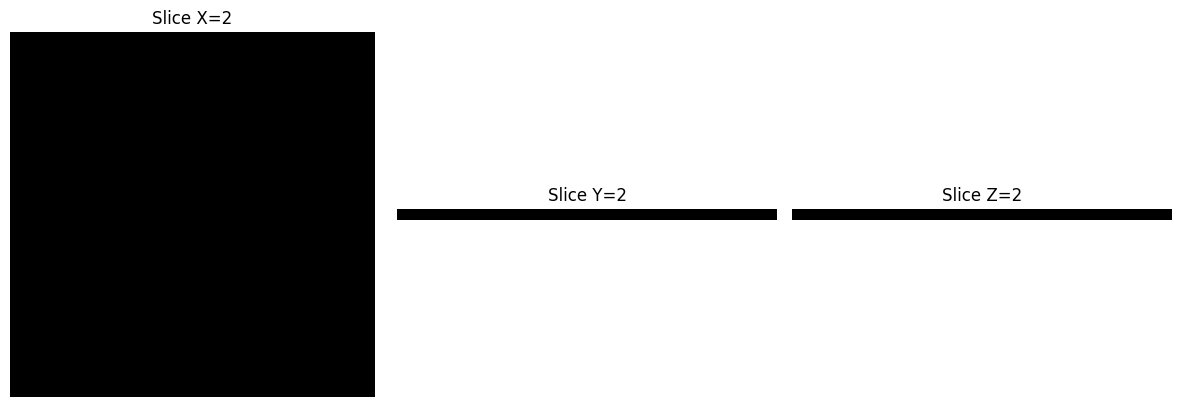

In [8]:
showTile(images[30])
showTile(masks[30], mask=True)

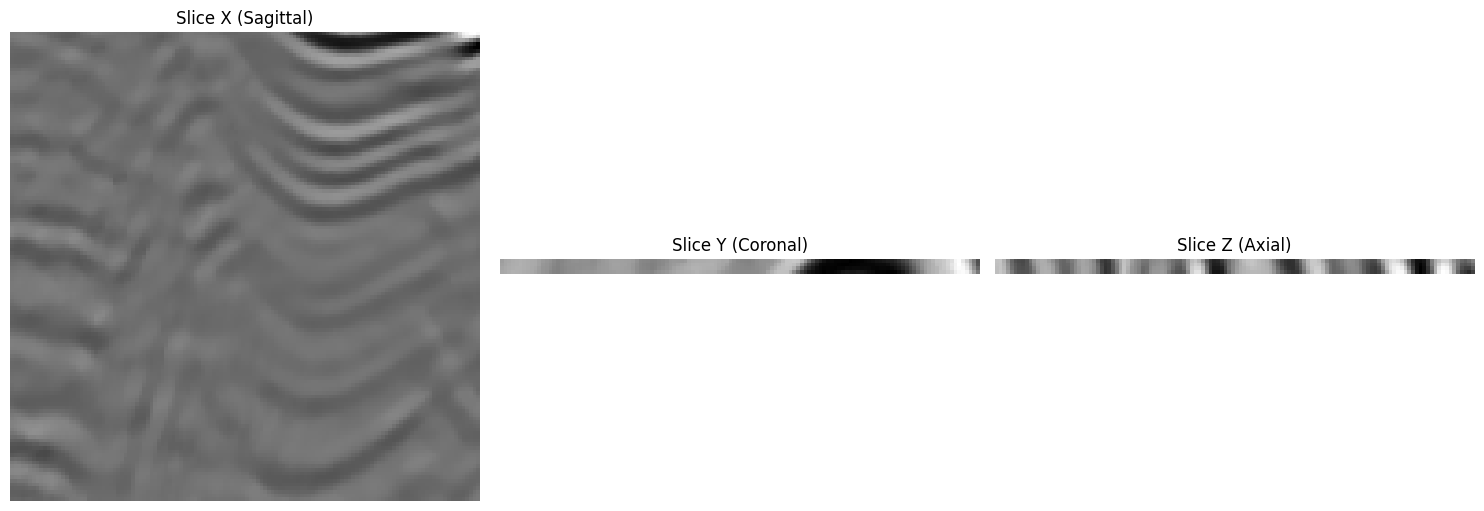

In [9]:
pasteMask(images[30], masks[30])

In [10]:
len(images) == len(masks)

True

In [11]:
images[0].shape

(4, 128, 128)

# SPLITS DOS DADOS

In [12]:
VAL_SIZE  = 0.10
TEST_SIZE = 0.10
VAL_SIZE  = VAL_SIZE / (1 - TEST_SIZE)

In [13]:
xTemp, xTest, yTemp, yTest = train_test_split(images, masks, test_size=TEST_SIZE, random_state=42)
del images, masks
xTrain, xVal, yTrain, yVal = train_test_split(xTemp, yTemp, test_size=VAL_SIZE, random_state=42)
del xTemp, yTemp

print(f'train: {len(yTrain)} files')
print(f'val:   {len(yVal)} files')
print(f'test:  {len(yTest)} files')

train: 17816 files
val:   2227 files
test:  2227 files


# SALVANDO DADOS

In [14]:
class Saver:
    def __init__(self, target='Processed'):
        self.DIR   = os.path.join(f'Database', target)
        self.index = 0
        
        for split in ['train', 'val', 'test']:
            setFolder(f'{self.DIR}/{split}/images')
            setFolder(f'{self.DIR}/{split}/masks')

    def to(self, split, img, mask):
        path = os.path.join(self.DIR, split)
        self.index = (self.index + 1)

        np.save(f'{path}/images/img_{self.index}.npy', img)
        np.save(f'{path}/masks/img_{self.index}.npy', mask)    

    def dataset(self, split, images, masks):
        for img, mask in zip(images, masks):
            self.to(split, img, mask)

            if AUG_PER_IMAGE > 0 and split == 'train':
                xData, yData = aug.compute(img, mask, AUG_PER_IMAGE)
                
                for img, mask in zip(xData, yData):
                    self.to(split, img, mask)

        total = os.listdir(f"{self.DIR}/{split}/images").__len__()
        print(f'{split}: {total} images')


saver = Saver('Processed')
saver.dataset('train', xTrain, yTrain)
saver.dataset('val',   xVal,   yVal)
saver.dataset('test',  xTest,  yTest)
del xTrain, yTrain, xVal, yVal, xTest, yTest

train: 17816 images


val: 2227 images


test: 2227 images


In [15]:
data = {
   'dataset': 'dataset1',
   'img_size': IMG_SIZE,
   'n_aug': AUG_PER_IMAGE, 
   'step': OPTIONS.get('step'),
   'n_images': n_images,
   'multiclass': MULTICLASS
}

with open(f'Database/info.json', 'w', encoding='utf-8') as file:
   json.dump(data, file, ensure_ascii=False, indent=4)

data

{'dataset': 'dataset1',
 'img_size': (4, 128, 128),
 'n_aug': 0,
 'step': 3,
 'n_images': 22270,
 'multiclass': True}

# VISUALIZAÇÃO

showing img 0


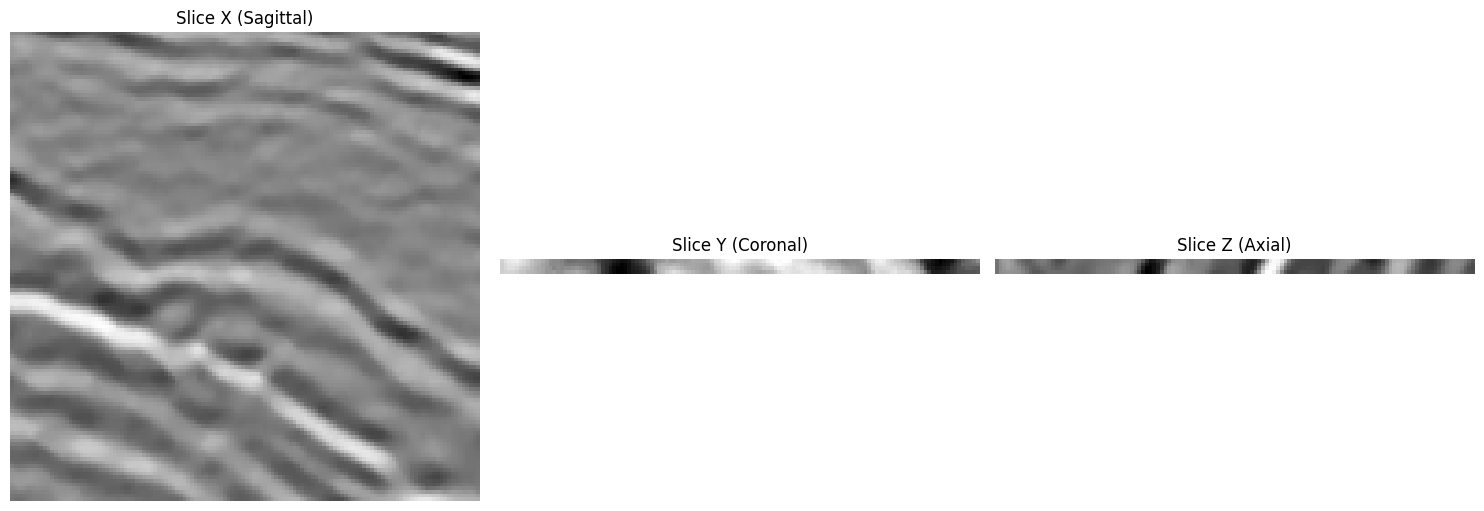

showing img 1


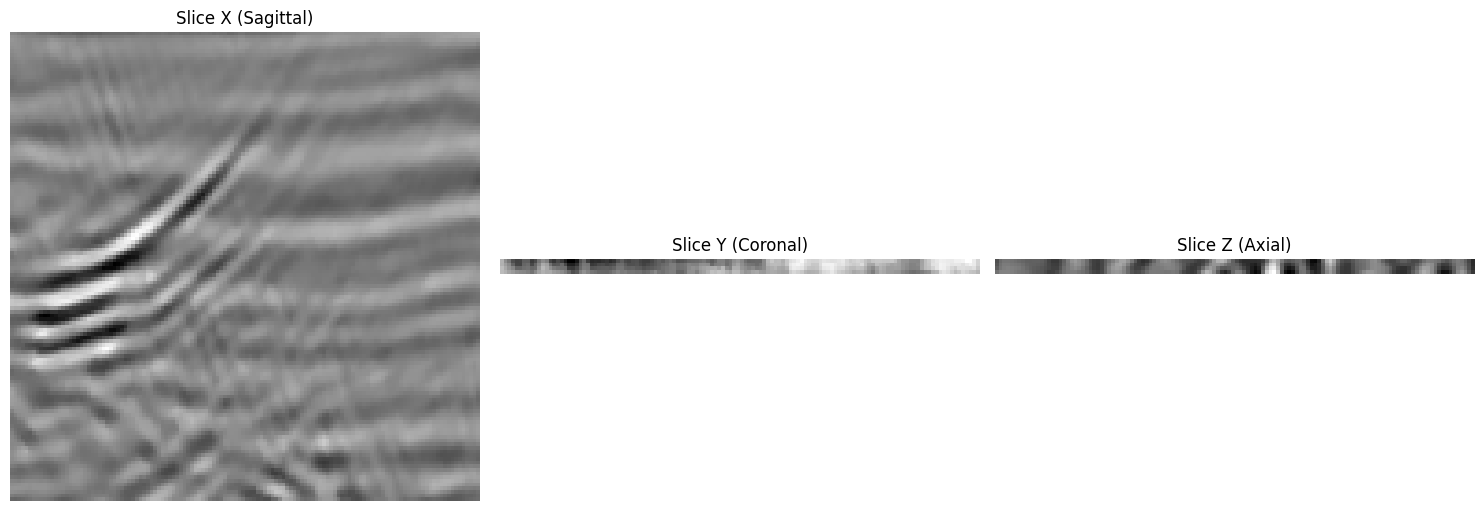

showing img 2


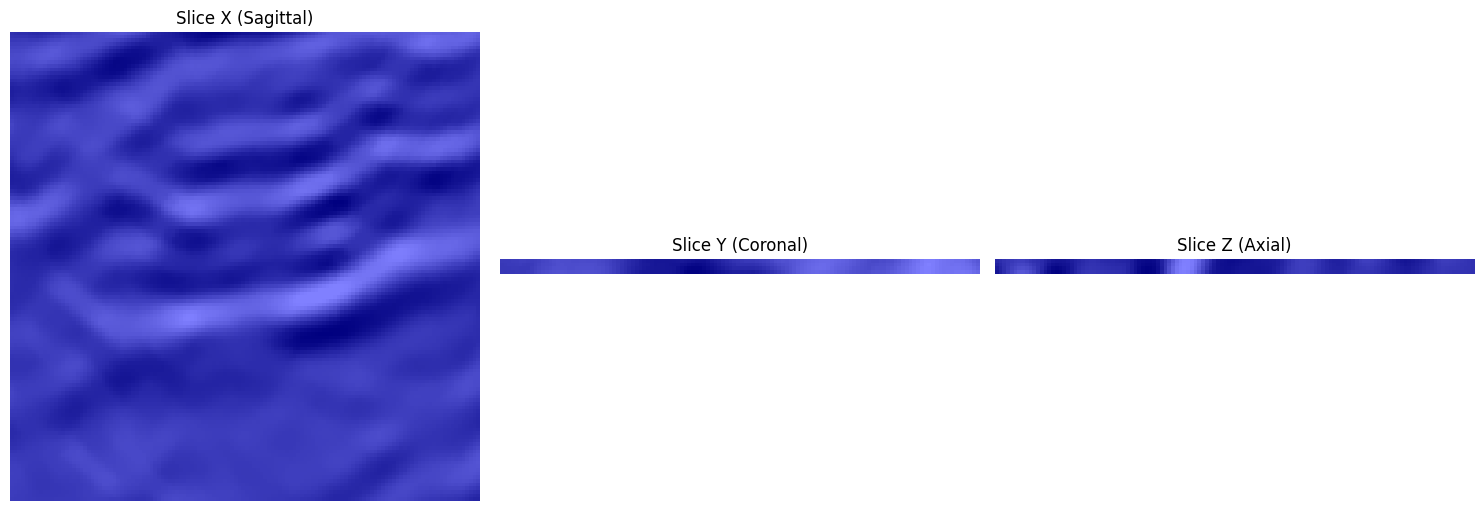

showing img 3


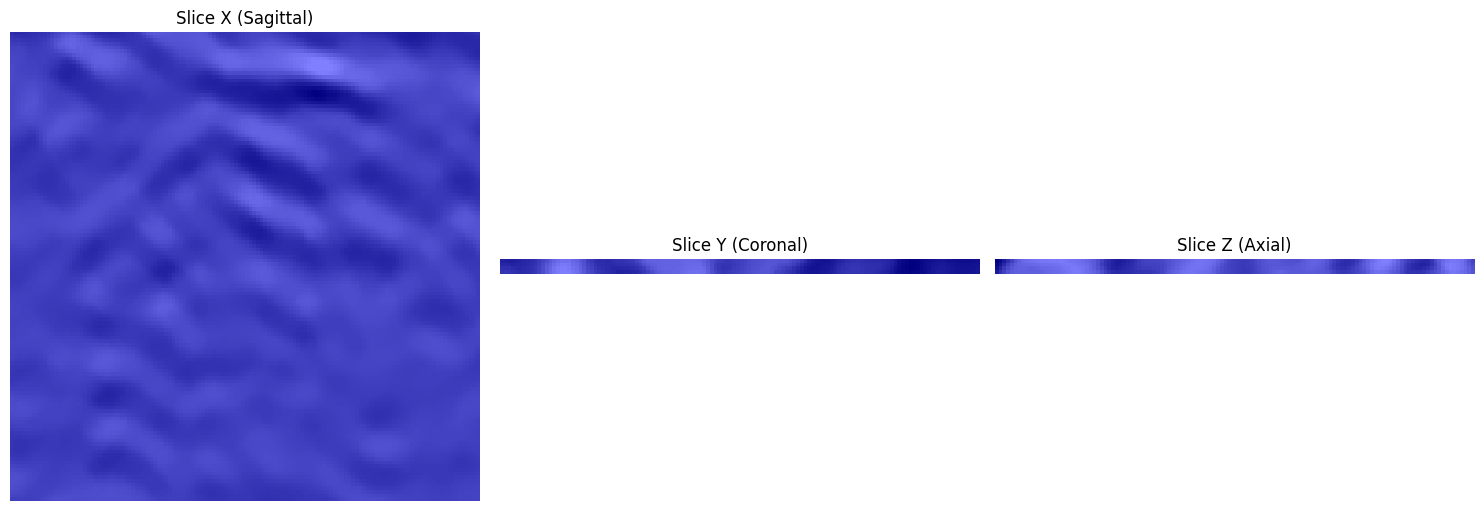

showing img 4


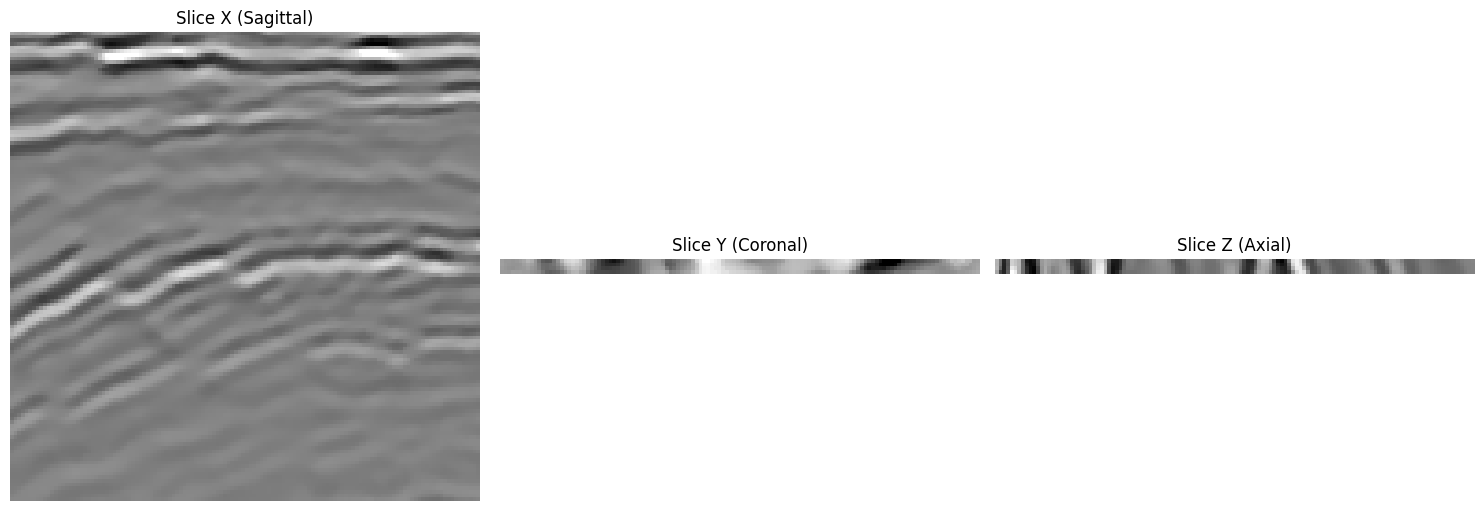

In [16]:
for i in range(5):
    print('showing img', i)
    img = np.load(getFile('Database/Processed/train/images', i))
    msk = np.load(getFile('Database/Processed/train/masks',  i))
    pasteMask(img, msk)